### Project Attractor

💡 **Nota Bene:** I'm moving all the library imports here

In [1]:
# !pip install scikit-learn

In [ ]:
import os                                   # operating system and path management
import numpy as np                          # numerical data
import matplotlib.pyplot as plt             # plotting graphs
import matplotlib
matplotlib.use('Agg')                       # crash prevention
import shutil                               # file management
import json                                 # JSON handling
import torch                                # GPU computing library
import collections                          # specialized data containers
import gc                                   # garbage collector for memory cleanup
import re                                   # regular expressions for string cleaning and searches
import cv2 # computer vision
import pickle                               # Serialization and saving of trained machine learning models to disk (for SVM)

from PIL import Image, ImageDraw, ImageFont # Loading and transforming images, as well as drawing text and borders
from ultralytics import YOLO                # Detecting people and objects using the YOLO11x model
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor # Loading the Qwen2-VL-7B-Instruct multimodal language model
from qwen_vl_utils import process_vision_info # Preparation for Qwen2-VL
from IPython.display import display, Image as IPyImage, HTML # Displaying images in the notebook

import torchvision.models as models         # computer vision neural networks (including ResNet50)
import torchvision.transforms as transforms # image preprocessing for neural networks
from sklearn.svm import OneClassSVM    # One-Class Support Vector Machine


💡 **Nota Bene:** Connecting my local graphics card and running a test

In [3]:
# Явно переключаем устройство на CUDA
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"CUDA: {gpu_name}")
else:
    print("CPU")
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Загружаем модель сразу на GPU
model = YOLO("yolo11x.pt").to("cuda")

print(f"Модель загружена на: {model.device}")

# Тестовый прогон на заглушке (создадим случайный тензор, чтобы проверить скорость)

test_img = np.zeros((640, 640, 3), dtype=np.uint8)
results = model.predict(source=test_img, conf=0.5)

print("Тест скорости завершен успешно.")

CUDA: NVIDIA GeForce RTX 5090
Модель загружена на: cuda:0

0: 640x640 (no detections), 11.5ms
Speed: 7.8ms preprocess, 11.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Тест скорости завершен успешно.


In [4]:
def validate_image_for_pipeline(img_path, yolo_model, min_confidence=0.5):
    """
    Проверяет изображение перед добавлением в контур обработки:
    - Наличие хотя бы одного человека (класс 0 в COCO).
    """
    if not os.path.exists(img_path):
        return False, "Файл не найден"

    # Запуск YOLO для детекции людей
    results = yolo_model(img_path, classes=[0], verbose=False)
    boxes = results[0].boxes
    
    if len(boxes) == 0:
        return False, "Нет людей на изображении"

    return True, "Пройдено успешно"

💡 **Nota Bene:** WWe filter out photos that do not contain people.
What should we do if there is more than one person in the photo?
What should we do if there are children in the photo?
What should we do if the photo contains copyright notices or watermarks from commercial photographs?
What should we do if the photo contains something that violates the laws of the country where it will be used?

In [5]:
# Конфигуратор пайплайнов
RUN_JSON_PIPELINE = True  # Переключите в True, если нужно прогнать Qwen2-VL
RUN_SVM_PIPELINE = True    # Переключите в False, если SVM инференс не нужен

In [6]:
# Папки для организации и тестирования (JSON и SVM пайплайны)
input_dir = "../data/01_my_taste_profiles"
output_dir = "../data/02_processed_pics"
test_dir = "../data/03_persons_pics"
tmp_dir = "../data/04_tmp_crops"
results_JSON_dir = "../data/05_results_JSON"
results_SVM_dir = "../data/06_results_SVM"
model_dir = "../models/svm_weights"
model_path = "../models/Qwen2-VL-7B-Instruct" # Указываем локальную папку

# Создаем необходимые директории для обоих пайплайнов, если их нет
os.makedirs(output_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(tmp_dir, exist_ok=True)
os.makedirs(results_JSON_dir, exist_ok=True)
os.makedirs(results_SVM_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

💡 **Nota Bene:**  Added test photos to the “03_persons_pics” folder


Test0fromTasteFolder - Copied from the 01_my_taste_profiles folder to 03_persons_pics

The following three test photos that I added to the 03_persons_pics folder were not in the 01_my_taste_profiles folder:

Test1New - A photo of the same person used to train the model

Test2couple - a photo of the person used to train the model, paired with another person

Test3back - a full-length photo of the person used to train the model, standing with their back to the camera (test for body shape and clothing)

Translated with DeepL.com (free version)

In [7]:
# 1. Инициализация детектирующей модели (YOLO)
print("Загрузка YOLO11x для фильтрации...")
yolo_model = YOLO("yolo11x.pt").to("cuda")

Загрузка YOLO11x для фильтрации...


In [8]:
# 2. Инициализация основной модели (Qwen) с корректным относительным путем
print("Загрузка Qwen2-VL...")
model_path = "../models/Qwen2-VL-7B-Instruct"

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_path, torch_dtype=torch.bfloat16, device_map="cuda"
)
processor = AutoProcessor.from_pretrained(model_path)

Загрузка Qwen2-VL...


Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

In [9]:
# УЛУЧШЕННЫЙ ПРОМПТ С ГЛОБАЛЬНОЙ ТАКСОНОМИЕЙ И АЛФАВИТНОЙ СОРТИРОВКОЙ для JSON-пайплайна
system_prompt = """
You are a strict, professional image classifier specializing in predictive modeling of human visual attractiveness. Output ONLY JSON.
RULES:
1. STRICT NEGATIVE CONSTRAINT: NEVER hallucinate. If a body part (feet, hands, chest) is out of frame or covered by clothing, its corresponding array MUST remain exactly [].
2. Do NOT infer "Barefoot" if feet are not visible in the image.
3. Do NOT infer "Nipple piercing" if bare breasts are not clearly visible. ABSOLUTE CONSTRAINT: If the chest area is covered by thick clothing (jackets, coats, sweaters) or large objects (bows, props), "modifications_and_piercings" MUST NOT contain "Nipple piercing".
4. Do NOT infer "Gloves" if bare hands/fingers are visible holding a phone.
5. "Cosplay" requires explicit, undeniable costume elements (e.g., wigs, armor, anime uniforms). Do not tag casual brightly colored clothing as Cosplay.
6. Extract attributes strictly using the provided nested hierarchy. Arrays MUST contain exact string matches from the taxonomy.
7. Kinesics & Posture: assign ONLY if body language is clearly visible.
8. Combine colors, types, and materials systematically for apparel based ONLY on exact pixel evidence.
9. You MUST extract MULTIPLE traits if applicable. For hair, always try to combine color, length, and texture in the array (e.g., ["Blonde", "Long hair", "Wet hair"]).

Taxonomy:
Tier 1 (Head, Identity & Microexpressions): 
age_bracket: [Age 18-22, Age 23-29, Age 30-39, Age 40-49, Age 50-59, Age 60+]
gender: [Female, Male]
ethnicity: [Arab, Black, Chinese, English, French, German, Hispanic, Indian, Italian, Japanese, Korean, Mediterranean, Mixed, Persian, Scandinavian, Slavic, Southeast Asian, Taiwanese, White]
evolutionary_facial_markers: [Carotenoid pigmentation, Masculine dimorphism, Neotenous features, Symmetrical features]
hair_style: [Bald, Bangs, Black hair, Blonde, Braids, Brunette, Long hair, Messy hair, Neon dyed, Ponytail, Redhead, Short hair, Wet hair]
eye_color: [Blue, Brown, Green, Grey, Hazel, Heterochromia]
cosmetics_and_styling: [Bimboification, Eyeliner heavy, Glossy lips, Lipstick bright, Lipstick dark, No makeup, Smudged makeup]
expression_and_microkinesics: [Biting lip, Dilated pupils, Direct stare, Flushed skin, Forced smile, Genuine smile, Licking lips, Looking down, Looking up, Parted lips]

Tier 2 (Body Morphology, Modifications & Kinesics): 
body_type_and_morphometrics: [Athletic, BBW, Curvy, Hourglass, Lordosis posture, Pear-shape, Petite, Pronounced WHR, Skinny, Tall, V-shape torso, X-shape]
posture_and_adaptors: [Arching back, Closed posture, Crossed limbs, Forward lean, Kneeling, Neck exposure, Open stance, Stroking hair, Touching collarbone, Touching face]
paraphilic_focus_zones: [General framing, Maschalagnia focus, Mazophilia focus, Oculophilia focus, Podophilia focus, Pygophilia focus]
skin_details: [Freckles, Glossy oiled, Pale, Stretch marks, Sweaty, Tan lines, Veins]
body_hair: [Body hair, Natural, Smooth]
modifications_and_piercings: [Body piercing, Braces, Elf ears, Facial piercing, Fangs, Genital piercing, Intimate tattoos, Navel piercing, Neck tattoo, Nipple piercing, Septum ring, Sleeve tattoo, Tattoos heavy]
nails_styling: [Acrylic nails, Black nails, French manicure, Long nails, Natural nails, Neon nails, Nude nails, Painted nails, Pastel nails, Red nails, Short nails, Stiletto nails]

Tier 3 (Apparel, Subcultural Archetypes & Fetish Accents): 
archetypes_and_uniforms: [Alt, Boss, Bride, Businessman, Businesswoman, Cheerleader, Construction, Cosplay, Cowboy, Cowgirl, Firefighter, Flight attendant, French maid, Gamer Girl, GFE, Judge, Medical, MILF, Military, Office formal, Police, Professor, Sailor, Secretary, Ski wear, Student, Teacher, Tennis player, Waiter, Widow]
clothing_types: [Basic underwear, Blouse, Business suit, Crop top, Dress, Fitness gear, Hoodie, Jeans, Leather jacket, Leggings, Maxi skirt, Midi skirt, Miniskirt, Oversized t-shirt, Ripped jeans, Robe, Shorts, Skinny jeans, Sportswear, Sweater, Swimsuit, Tank top]
footwear_and_hosiery: [Ankle boots, Barefoot, Fishnets, Flat shoes, Heavy combat boots, Opaque tights, Seamed stockings, Sheer tights, Sneakers, Stilettos, Thigh high boots]
colors: [Beige, Black, Blue, Brown, Green, Grey, Khaki, Metallic, Multi-colored, Neon, Orange, Pastel, Pink, Purple, Red, White, Yellow]
materials: [Cotton, Denim, Fishnet, Fur, Lace, Latex, Leather, Lycra, Mesh, Nylon, PVC, Silk, Velvet]
fetish_and_specific_items: [Blindfold, Bustier, Choker, Collar, Corset, Gag, Glasses, Gloves, Handbag, Harness, Hat, Leash, Scarf]

Tier 4 (Environment, Context & Power Dynamics): 
camera_angle_and_dynamics: [Eye level, From behind, High angle, Low angle, POV, Side profile]
lighting: [Cinematic, Dark low key, Natural lighting, Neon, Overexposed flash, Studio lighting, Unproduced lighting]
location: [Balcony, Bathroom, Beach, Bedroom, Car interior, City street, Classroom, Corporate office, Dungeon, Gym, Hotel room, Library, Living room, Medical room, Nature, Nightclub, Outdoors, Pool, Restaurant]
props: [Bed, Book, Car keys, Chair, Cigarette, Coffee cup, Handcuffs, Laptop, Mirror, Phone selfie, Riding crop, Steering wheel, Whip, Wine glass]

JSON Schema:
{"image_metadata": {"tier_1_identity": {"age_bracket": "", "gender": "", "ethnicity": [], "evolutionary_facial_markers": [], "hair_style": [], "eye_color": [], "cosmetics_and_styling": [], "expression_and_microkinesics": []}, "tier_2_body_and_kinesics": {"body_type_and_morphometrics": [], "posture_and_adaptors": [], "paraphilic_focus_zones": [], "skin_details": [], "body_hair": [], "modifications_and_piercings": [], "nails_styling": []}, "tier_3_apparel_and_fetish": {"archetypes_and_uniforms": [], "clothing_types": [], "footwear_and_hosiery": [], "colors": [], "materials": [], "fetish_and_specific_items": []}, "tier_4_environment_and_dynamics": {"camera_angle_and_dynamics": [], "lighting": [], "location": [], "props": []}}}
"""


In [10]:
def extract_json(text):
    start, end = text.find('{'), text.rfind('}') + 1
    return json.loads(text[start:end]) if start != -1 and end != -1 else None

In [11]:
# ЯЧЕЙКА: Инференс Qwen2-VL и фильтрация базовых фото (01_my_taste_profiles -> 02_processed_pics)
image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

for img_name in image_files:
    img_path = os.path.join(input_dir, img_name)
    
    # ЕДИНАЯ ТОЧКА ВАЛИДАЦИИ
    is_valid, reason = validate_image_for_pipeline(img_path, yolo_model)
    if not is_valid:
        print(f"Пропущено ({reason}): {img_name}")
        continue
    
    messages = [{"role": "user", "content": [{"type": "image", "image": img_path}, {"type": "text", "text": system_prompt}]}]
    
    inputs = processor(text=[processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)], 
                       images=process_vision_info(messages)[0], videos=None, padding=True, return_tensors="pt").to("cuda")

    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=512, temperature=0.05, do_sample=False)
        
    output_text = processor.batch_decode(generated_ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
    parsed = extract_json(output_text)
    
    if parsed:
        base_name = os.path.splitext(img_name)[0]
        with open(os.path.join(output_dir, f"{base_name}.json"), "w", encoding="utf-8") as f:
            json.dump(parsed, f, indent=4, ensure_ascii=False)
            
        if not os.path.exists(os.path.join(output_dir, img_name)):
            shutil.copy2(img_path, os.path.join(output_dir, img_name))
        
        print(f"Обработано и добавлено в базу: {img_name}")

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Обработано и добавлено в базу: 01.jpeg
Обработано и добавлено в базу: 02.jpeg
Обработано и добавлено в базу: 03.jpeg
Обработано и добавлено в базу: 04.jpeg
Обработано и добавлено в базу: 05.jpeg
Обработано и добавлено в базу: 06.jpeg
Обработано и добавлено в базу: 07.jpeg
Обработано и добавлено в базу: 08.jpeg
Обработано и добавлено в базу: 09.jpeg
Обработано и добавлено в базу: 10.jpeg
Обработано и добавлено в базу: 11.jpeg
Обработано и добавлено в базу: 12.jpeg
Обработано и добавлено в базу: 13.jpeg
Обработано и добавлено в базу: 14.jpeg
Обработано и добавлено в базу: 15.jpeg
Обработано и добавлено в базу: 16.jpeg
Обработано и добавлено в базу: 17.jpeg
Обработано и добавлено в базу: 18.jpeg
Обработано и добавлено в базу: 19.jpeg
Обработано и добавлено в базу: 20.jpeg
Обработано и добавлено в базу: 21.jpeg
Обработано и добавлено в базу: 22.jpeg
Обработано и добавлено в базу: 23.jpeg
Обработано и добавлено в базу: 24.jpeg
Обработано и добавлено в базу: 25.jpeg
Обработано и добавлено в 

In [12]:
def generate_seo_query(json_dir):
    categories = collections.defaultdict(collections.Counter)
    json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]

    for f_name in json_files:
        with open(os.path.join(json_dir, f_name), 'r', encoding='utf-8') as f:
            metadata = json.load(f).get('image_metadata', {})

            t1 = metadata.get('tier_1_identity', {})
            t3 = metadata.get('tier_3_apparel_and_fetish', {})
            t4 = metadata.get('tier_4_environment_and_dynamics', {})

            def add_to_counter(tier_dict, key, counter_name):
                val = tier_dict.get(key)
                if not val: return
                if isinstance(val, list):
                    categories[counter_name].update(val)
                elif isinstance(val, str):
                    categories[counter_name].update([val])

            add_to_counter(t1, 'gender', 'gender')
            add_to_counter(t1, 'ethnicity', 'ethnicity')
            add_to_counter(t1, 'hair_style', 'hair')
            add_to_counter(t1, 'eye_color', 'eyes')
            
            add_to_counter(t3, 'clothing_types', 'clothes')
            add_to_counter(t3, 'colors', 'colors')

            add_to_counter(t4, 'location', 'location')
            add_to_counter(t4, 'lighting', 'lighting')

    query_parts = []

    # 1. Базис (Beautiful White Female)
    gender = categories['gender'].most_common(1)[0][0] if categories['gender'] else "woman"
    eth = categories['ethnicity'].most_common(1)[0][0] if categories['ethnicity'] else ""
    query_parts.append(f"beautiful {eth} {gender}".strip().lower())

    # 2. Жесткая привязка волос (исключает подмес цветов одежды)
    if categories['hair']:
        top_hair = [h for h, _ in categories['hair'].most_common(3)]
        query_parts.append(f"\"{' '.join(top_hair)}\"")

    # 3. Глаза
    if categories['eyes']:
        eyes = categories['eyes'].most_common(1)[0][0]
        query_parts.append(f"\"{eyes} eyes\"")

    # 4. Жесткая привязка цвета к одежде
    color = categories['colors'].most_common(1)[0][0] if categories['colors'] else ""
    clothes = categories['clothes'].most_common(1)[0][0] if categories['clothes'] else ""
    if color and clothes:
        query_parts.append(f"\"{color} {clothes}\"")
    elif clothes:
        query_parts.append(f"\"{clothes}\"")

    # 5. Контекст среды
    loc = categories['location'].most_common(1)[0][0] if categories['location'] else ""
    light = categories['lighting'].most_common(1)[0][0] if categories['lighting'] else ""
    if loc or light:
        query_parts.append(f"{loc} {light}".strip())

    # Добавляем хвост для эстетики
    query_parts.append("aesthetic portrait photography")

    # Склейка и очистка лишних пробелов
    final_query = ' '.join(query_parts)
    return re.sub(r'\s+', ' ', final_query).strip()

# Запуск
search_query = generate_seo_query(output_dir)
print(f"SEO-запрос для Google:\n{search_query}")

SEO-запрос для Google:
beautiful white female "Long hair Blonde Wet hair" "Blue eyes" "Blue Dress" Beach Natural lighting aesthetic portrait photography


In [13]:
def generate_ai_diffusion_prompt(json_dir):
    categories = collections.defaultdict(collections.Counter)
    json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]

    for f_name in json_files:
        with open(os.path.join(json_dir, f_name), 'r', encoding='utf-8') as f:
            metadata = json.load(f).get('image_metadata', {})

            t1 = metadata.get('tier_1_identity', {})
            t2 = metadata.get('tier_2_body_and_kinesics', {})
            t3 = metadata.get('tier_3_apparel_and_fetish', {})
            t4 = metadata.get('tier_4_environment_and_dynamics', {})

            def add_to_counter(tier_dict, key, counter_name):
                val = tier_dict.get(key)
                if not val: return
                if isinstance(val, list):
                    categories[counter_name].update(val)
                elif isinstance(val, str):
                    categories[counter_name].update([val])

            add_to_counter(t1, 'gender', 'gender')
            add_to_counter(t1, 'ethnicity', 'ethnicity')
            add_to_counter(t1, 'hair_style', 'hair')
            add_to_counter(t1, 'eye_color', 'eyes')
            
            add_to_counter(t2, 'body_type_and_morphometrics', 'body')
            add_to_counter(t2, 'posture_and_adaptors', 'posture')
            
            add_to_counter(t3, 'clothing_types', 'clothes')
            add_to_counter(t3, 'colors', 'colors')
            add_to_counter(t3, 'archetypes_and_uniforms', 'archetypes')

            add_to_counter(t4, 'location', 'location')
            add_to_counter(t4, 'lighting', 'lighting')
            add_to_counter(t4, 'camera_angle_and_dynamics', 'angle')

    # 1. Базовые усилители фотографического качества
    prompt_parts = ["RAW photo", "masterpiece", "ultra-detailed", "8k resolution"]

    # 2. Определение субъекта (формат Danbooru / Stable Diffusion)
    gender = categories['gender'].most_common(1)[0][0] if categories['gender'] else "woman"
    eth = categories['ethnicity'].most_common(1)[0][0] if categories['ethnicity'] else "white"
    
    subject_tag = "1girl" if gender.lower() == "female" else "1boy"
    prompt_parts.append(f"{subject_tag}, beautiful {eth.lower()} {gender.lower()}")

    def get_top(counter_name, k=2):
        counter = categories.get(counter_name)
        if not counter: return []
        return [item.lower() for item, _ in counter.most_common(k)]

    # 3. Физические характеристики
    prompt_parts.extend(get_top('hair', 3))
    
    eyes = get_top('eyes', 1)
    if eyes: prompt_parts.append(f"{eyes[0]} eyes")
    
    prompt_parts.extend(get_top('body', 2))
    prompt_parts.extend(get_top('posture', 1))

    # 4. Одежда и контекст
    color = get_top('colors', 1)
    clothes = get_top('clothes', 2)
    if color and clothes:
        prompt_parts.append(f"{color[0]} {' '.join(clothes)}")
    elif clothes:
        prompt_parts.extend(clothes)

    archetype = get_top('archetypes', 1)
    if archetype and archetype[0] != "none":
        prompt_parts.extend(archetype)

    # 5. Окружение и работа камеры
    prompt_parts.extend(get_top('location', 1))
    prompt_parts.extend(get_top('lighting', 2))
    prompt_parts.extend(get_top('angle', 1))

    # Финализация оптическими модификаторами
    prompt_parts.append("dslr, soft lighting, volumetric lighting, highly detailed skin, photorealistic")

    # Очистка пустых значений и сборка строки через запятую
    final_prompt = ", ".join(filter(None, prompt_parts))
    return final_prompt

# Запуск генератора ИИ-промпта
ai_prompt = generate_ai_diffusion_prompt(output_dir)
print(f"Промпт для Stable Diffusion / Midjourney:\n{ai_prompt}")

Промпт для Stable Diffusion / Midjourney:
RAW photo, masterpiece, ultra-detailed, 8k resolution, 1girl, beautiful white female, long hair, blonde, wet hair, blue eyes, athletic, hourglass, forward lean, blue dress tank top, cosplay, beach, natural lighting, eye level, dslr, soft lighting, volumetric lighting, highly detailed skin, photorealistic


In [14]:
def generate_nanabanana_prompt(json_dir):
    categories = collections.defaultdict(collections.Counter)
    json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]

    for f_name in json_files:
        with open(os.path.join(json_dir, f_name), 'r', encoding='utf-8') as f:
            metadata = json.load(f).get('image_metadata', {})

            t1 = metadata.get('tier_1_identity', {})
            t2 = metadata.get('tier_2_body_and_kinesics', {})
            t3 = metadata.get('tier_3_apparel_and_fetish', {})
            t4 = metadata.get('tier_4_environment_and_dynamics', {})

            def count_tags(t_dict, key, c_name):
                v = t_dict.get(key)
                if not v: return
                if isinstance(v, list): categories[c_name].update(v)
                elif isinstance(v, str): categories[c_name].update([v])

            count_tags(t1, 'gender', 'gender')
            count_tags(t1, 'ethnicity', 'ethnicity')
            count_tags(t1, 'hair_style', 'hair')
            count_tags(t1, 'eye_color', 'eyes')
            count_tags(t1, 'expression_and_microkinesics', 'kinesics')
            count_tags(t2, 'body_type_and_morphometrics', 'body')
            count_tags(t2, 'posture_and_adaptors', 'posture')
            count_tags(t3, 'clothing_types', 'clothes')
            count_tags(t3, 'colors', 'colors')
            count_tags(t3, 'archetypes_and_uniforms', 'archetypes')
            count_tags(t4, 'location', 'location')
            count_tags(t4, 'lighting', 'lighting')
            count_tags(t4, 'camera_angle_and_dynamics', 'angle')

    def fetch_top(c_name, count=1):
        if not categories[c_name]: return []
        return [item.lower() for item, _ in categories[c_name].most_common(count)]

    sentences = []

    # 1. Формирование субъекта
    gender = fetch_top('gender')[0] if fetch_top('gender') else "woman"
    eth = fetch_top('ethnicity')[0] if fetch_top('ethnicity') else ""
    subject = f"{eth} {gender}".strip()
    
    sentences.append(f"A highly detailed, photorealistic portrait of a beautiful {subject}.")

    # 2. Лицо и микрокинесика
    hair = fetch_top('hair', 2)
    eyes = fetch_top('eyes')
    face_traits = []
    if hair: face_traits.append(f"{' and '.join(hair)} hair")
    if eyes: face_traits.append(f"{eyes[0]} eyes")
    if face_traits:
        sentences.append(f"The subject features {' and '.join(face_traits)}.")

    # 3. Морфология и поза
    body = fetch_top('body', 2)
    posture = fetch_top('posture')
    kinesics = fetch_top('kinesics')
    
    pose_desc = []
    if body: pose_desc.append(f"a {' and '.join(body)} physique")
    if posture: pose_desc.append(f"is posed with a {posture[0]}")
    if kinesics: pose_desc.append(f"shows a {kinesics[0]}")
    
    if pose_desc:
        body_sentence = f"She has {pose_desc[0]}"
        if len(pose_desc) > 1:
            body_sentence += f" and {' and '.join(pose_desc[1:])}"
        sentences.append(body_sentence + ".")

    # 4. Одежда и архетипы
    color = fetch_top('colors')
    clothes = fetch_top('clothes', 2)
    archetype = fetch_top('archetypes')
    
    if color and clothes:
        apparel = f"{color[0]} {' and '.join(clothes)}"
        style = f" in a {archetype[0]} style" if archetype and archetype[0] != "none" else ""
        sentences.append(f"She is wearing a {apparel}{style}.")

    # 5. Окружение
    loc = fetch_top('location')
    light = fetch_top('lighting', 2)
    angle = fetch_top('angle')
    
    env = []
    if loc: env.append(f"takes place in a {loc[0]}")
    if light: env.append(f"is illuminated by {' and '.join(light)}")
    if angle: env.append(f"is captured from a {angle[0]}")
    
    if env:
        sentences.append(f"The scene {' and '.join(env)}.")

    return " ".join(sentences)

nanabanana_prompt = generate_nanabanana_prompt(output_dir)
print(f"Промпт для Nano Banana:\n{nanabanana_prompt}")

Промпт для Nano Banana:
A highly detailed, photorealistic portrait of a beautiful white female. The subject features long hair and blonde hair and blue eyes. She has a athletic and hourglass physique and is posed with a forward lean and shows a genuine smile. She is wearing a blue dress and tank top in a cosplay style. The scene takes place in a beach and is illuminated by natural lighting and is captured from a eye level.


In [15]:
# 1. КОМПИЛЯЦИЯ МАТРИЦЫ ПРЕДПОЧТЕНИЙ
def compile_taste_matrix(json_dir):
    matrix = collections.defaultdict(collections.Counter)
    files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
    
    for f_name in files:
        with open(os.path.join(json_dir, f_name), 'r', encoding='utf-8') as f:
            data = json.load(f).get('image_metadata', {})
            
            # Извлекаем все параметры со всех уровней
            for tier in data.values():
                for key, val in tier.items():
                    if not val: continue
                    if isinstance(val, list):
                        matrix[key].update(val)
                    else:
                        matrix[key].update([val])
                        
    # Нормализация данных (превращаем абсолютные числа в вероятности от 0.0 до 1.0)
    normalized = {}
    for key, counter in matrix.items():
        total = sum(counter.values())
        normalized[key] = {k: v/total for k, v in counter.items()}
        
    return normalized

taste_matrix = compile_taste_matrix(output_dir)

# 2. АЛГОРИТМ ОЦЕНКИ (СКОРИНГА)
def calculate_attractor_score(person_json, matrix):
    score = 0.0
    max_possible = 0.0
    
    # Каскадные множители важности (можно настраивать)
    weights = {
        'tier_1_identity': 1.5,
        'tier_2_body_and_kinesics': 1.2,
        'tier_3_apparel_and_fetish': 0.8,
        'tier_4_environment_and_dynamics': 0.3
    }
    
    for tier_name, tier_data in person_json.items():
        tier_weight = weights.get(tier_name, 1.0)
        
        for key, val in tier_data.items():
            if key not in matrix: continue
            
            # Добавляем максимальный потенциал параметра для расчета процентов
            if matrix[key]:
                max_possible += tier_weight * max(matrix[key].values())
            
            if not val: continue
            items = val if isinstance(val, list) else [val]
            
            # Начисление баллов за совпадения
            for item in items:
                if item in matrix[key]:
                    score += tier_weight * matrix[key][item]
                    
    if max_possible == 0: return 0.0
    final_percentage = (score / max_possible) * 100
    return round(final_percentage, 1)

print("Матрица эталонного вкуса скомпилирована. База для скоринга готова.")

Матрица эталонного вкуса скомпилирована. База для скоринга готова.


In [16]:
if RUN_JSON_PIPELINE:
    results_pool = []
    print("Начат анализ новых лиц алгоритмом JSON. Пожалуйста, подождите...")

    gc.collect()
    torch.cuda.empty_cache()

    image_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img_name in image_files:
        img_path = os.path.join(test_dir, img_name)
        original_img = Image.open(img_path).convert("RGB")
        width, height = original_img.size
        
        results = yolo_model(img_path, classes=[0], verbose=False)
        boxes = results[0].boxes.xyxy.cpu().numpy()
        
        for idx, box in enumerate(boxes):
            x1, y1 = max(0, int(box[0])), max(0, int(box[1]))
            x2, y2 = min(width, int(box[2])), min(height, int(box[3]))
            
            if x2 - x1 < 50 or y2 - y1 < 50: continue
            
            crop_img = original_img.crop((x1, y1, x2, y2)).copy()
            
            if crop_img.width > 1024 or crop_img.height > 1024:
                crop_img.thumbnail((1024, 1024))
            
            base_name = os.path.splitext(img_name)[0]
            tmp_path = os.path.join(tmp_dir, f"{base_name}_crop_{idx}.jpg")
            crop_img.save(tmp_path)
            
            messages = [{"role": "user", "content": [{"type": "image", "image": tmp_path}, {"type": "text", "text": system_prompt}]}]
            inputs = processor(text=[processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)], 
                               images=process_vision_info(messages)[0], padding=True, return_tensors="pt").to("cuda")
                               
            with torch.no_grad():
                generated_ids = model.generate(**inputs, max_new_tokens=512, do_sample=False)
            
            output_text = processor.batch_decode(generated_ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
            parsed = extract_json(output_text)
            
            if parsed:
                metadata = parsed.get("image_metadata", {})
                score = calculate_attractor_score(metadata, taste_matrix)
                
                json_path = os.path.join(tmp_dir, f"{base_name}_crop_{idx}.json")
                with open(json_path, "w", encoding="utf-8") as f:
                    json.dump(parsed, f, indent=4, ensure_ascii=False)
                
                results_pool.append({
                    "score": score,
                    "path": tmp_path,
                    "filename": f"{base_name}_crop_{idx}.jpg"
                })
                
                print(f"[JSON] Успешно обработан: {base_name}_crop_{idx}")
                
            del crop_img
            del inputs, generated_ids, output_text
            torch.cuda.empty_cache()
            gc.collect()

        original_img.close()

    print("\n[СИСТЕМА] Оффлоадинг нейросетей из VRAM в RAM...")
    try:
        model.to("cpu")
        yolo_model.to("cpu")
    except NameError:
        pass
    gc.collect()
    torch.cuda.empty_cache()
    print("[СИСТЕМА] Видеопамять очищена.")

    results_pool.sort(key=lambda x: x["score"], reverse=True)
    top_20 = results_pool[:20]

    cache_file = os.path.join(results_JSON_dir, "top_20_cache.json")
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(top_20, f, ensure_ascii=False, indent=4)

    print(f"[СИСТЕМА] Инференс JSON завершен. Данные сохранены в кэш: {cache_file}")
else:
    print("[СИСТЕМА] Пайплайн JSON отключен в конфигураторе.")

Начат анализ новых лиц алгоритмом JSON. Пожалуйста, подождите...
[JSON] Успешно обработан: NB_Generated_Image_00_crop_0
[JSON] Успешно обработан: NB_Generated_Image_00_crop_1
[JSON] Успешно обработан: NB_Generated_Image_01_crop_0
[JSON] Успешно обработан: NB_Generated_Image_02_crop_0
[JSON] Успешно обработан: NB_Generated_Image_03_crop_0
[JSON] Успешно обработан: NB_Generated_Image_04_crop_0
[JSON] Успешно обработан: NB_Generated_Image_04_crop_1
[JSON] Успешно обработан: NB_Generated_Image_04_crop_2
[JSON] Успешно обработан: NB_Generated_Image_04_crop_3
[JSON] Успешно обработан: NB_Generated_Image_04_crop_4
[JSON] Успешно обработан: NB_Generated_Image_04_crop_5
[JSON] Успешно обработан: NB_Generated_Image_04_crop_6
[JSON] Успешно обработан: NB_Generated_Image_04_crop_7
[JSON] Успешно обработан: NB_Generated_Image_05_crop_0
[JSON] Успешно обработан: NB_Generated_Image_05_crop_1
[JSON] Успешно обработан: NB_Generated_Image_05_crop_2
[JSON] Успешно обработан: NB_Generated_Image_05_crop_3


=== ТАБЛИЦА РЕЛЕВАНТНОСТИ (TOP-20) по алгоритму JSON ===
Ранг  | Скор    | Файл
--------------------------------------------------
#1    | 99.3%  | test4nofocus_crop_0.jpg
#2    | 97.9%  | Test5document_crop_0.jpg
#3    | 97.0%  | Test0fromTasteFolder_crop_0.jpg
#4    | 95.0%  | Test3back_crop_0.jpg
#5    | 94.7%  | NB_Generated_Image_22_crop_0.jpg
#6    | 93.2%  | NB_Generated_Image_12_crop_6.jpg
#7    | 92.7%  | test9halfface_crop_0.jpg
#8    | 91.7%  | NB_Generated_Image_41_crop_8.jpg
#9    | 91.3%  | Test1New_crop_0.jpg
#10   | 90.9%  | NB_Generated_Image_02_crop_0.jpg
#11   | 90.9%  | NB_Generated_Image_35_crop_8.jpg
#12   | 90.8%  | NB_Generated_Image_35_crop_16.jpg
#13   | 90.5%  | NB_Generated_Image_41_crop_2.jpg
#14   | 90.2%  | NB_Generated_Image_24_crop_0.jpg
#15   | 90.1%  | NB_Generated_Image_00_crop_1.jpg
#16   | 88.6%  | NB_Generated_Image_41_crop_3.jpg
#17   | 87.7%  | Test2couple_crop_1.jpg
#18   | 87.5%  | NB_Generated_Image_28_crop_0.jpg
#19   | 87.2%  | NB_Generated

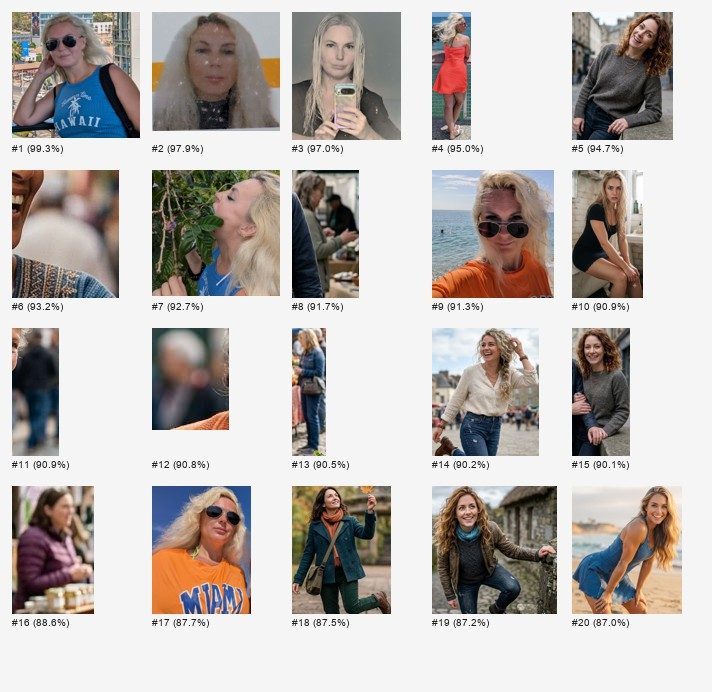

In [17]:
# ЯЧЕЙКА 14: Визуализация результатов JSON (миниатюры 128x128 для приватности)
if RUN_JSON_PIPELINE:
    cache_file = os.path.join(results_JSON_dir, "top_20_cache.json")
    if not os.path.exists(cache_file):
        print("Кэш не найден. Сначала выполните ячейку инференса JSON.")
    else:
        with open(cache_file, "r", encoding="utf-8") as f:
            top_20 = json.load(f)

        print("=== ТАБЛИЦА РЕЛЕВАНТНОСТИ (TOP-20) по алгоритму JSON ===")
        print(f"{'Ранг':<5} | {'Скор':<7} | {'Файл'}")
        print("-" * 50)
        for rank, item in enumerate(top_20, 1):
            print(f"#{rank:<4} | {item['score']}%{'':<1} | {item['filename']}")
        print("-" * 50 + "\n")

        if top_20:
            print("[СИСТЕМА] Рендер сетки изображений JSON через PIL...")
            cols, thumb_size, padding = 5, (128, 128), 12
            
            n_images = len(top_20)
            rows = (n_images + cols - 1) // cols
            grid_width = cols * thumb_size[0] + (cols + 1) * padding
            grid_height = rows * (thumb_size[1] + 30) + (rows + 1) * padding
            
            master_grid = Image.new('RGB', (grid_width, grid_height), color=(245, 245, 245))
            draw_grid = ImageDraw.Draw(master_grid)
            
            try:
                font = ImageFont.truetype("arial.ttf", 10)
            except IOError:
                font = ImageFont.load_default()
                
            for idx, item in enumerate(top_20):
                if idx >= cols * rows: break
                img_path = item["path"]
                r, c = divmod(idx, cols)
                x = padding + c * (thumb_size[0] + padding)
                y = padding + r * (thumb_size[1] + 30)
                
                try:
                    with Image.open(img_path) as img:
                        img_rgb = img.convert("RGB")
                        img_rgb.thumbnail(thumb_size)
                        
                        master_grid.paste(img_rgb, (x, y))
                        
                        caption = f"#{idx+1} ({item['score']}%)"
                        draw_grid.text((x, y + thumb_size[1] + 2), caption, fill=(30, 30, 30), font=font)
                except Exception as e:
                    pass

            safe_output_path = os.path.join(results_JSON_dir, "top_20_grid_result.jpg")
            master_grid.save(safe_output_path, format='JPEG', quality=90)
            master_grid.close() 
            
            print(f"[СИСТЕМА] Графическая сетка по алгоритму JSON аппаратно сохранена на SSD: {safe_output_path}")
            display(IPyImage(filename=safe_output_path))
        else:
            print("В целевой директории не найдено ни одного подходящего совпадения по алгоритму JSON.")

💡 **Nota Bene:** The Kernel crashed while executing code in the current cell or a previous cell. 
Please review the code in the cell(s) to identify a possible cause of the failure. 
Click <a href='https://aka.ms/vscodeJupyterKernelCrash'>here</a> for more info. 
View Jupyter <a href='command:jupyter.viewOutput'>log</a> for further details.

In [18]:
# ЯЧЕЙКА: Инициализация ResNet50 и Обучение One-Class SVM (Папка 02)
if RUN_SVM_PIPELINE:
    print("\n[СИСТЕМА] Инициализация архитектуры ResNet50...")
    resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    resnet = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device).eval()
    
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    def extract_features(img_path):
        try:
            img = Image.open(img_path).convert('RGB')
            tensor = preprocess(img).unsqueeze(0).to(device)
            with torch.no_grad():
                return resnet(tensor).squeeze().cpu().numpy()
        except:
            return None

    print("[СИСТЕМА] Запуск векторизации и обучения SVM...")
    train_files = [f for f in os.listdir(output_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    X_train = []
    
    for file in train_files:
        feat = extract_features(os.path.join(output_dir, file))
        if feat is not None:
            X_train.append(feat)
            print(f"[OK] Векторизован: {file}")

    if X_train:
        X_train = np.array(X_train)
        clf = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)
        clf.fit(X_train)
        
        with open(os.path.join(model_dir, "oc_svm_model.pkl"), 'wb') as f:
            pickle.dump(clf, f)
        print(f"Матрица признаков: {X_train.shape}. Модель SVM сохранена.")
    else:
        print("[ОШИБКА] Нет валидных изображений для обучения SVM.")


[СИСТЕМА] Инициализация архитектуры ResNet50...
[СИСТЕМА] Запуск векторизации и обучения SVM...
[OK] Векторизован: 01.jpeg
[OK] Векторизован: 02.jpeg
[OK] Векторизован: 03.jpeg
[OK] Векторизован: 04.jpeg
[OK] Векторизован: 05.jpeg
[OK] Векторизован: 06.jpeg
[OK] Векторизован: 07.jpeg
[OK] Векторизован: 08.jpeg
[OK] Векторизован: 09.jpeg
[OK] Векторизован: 10.jpeg
[OK] Векторизован: 11.jpeg
[OK] Векторизован: 12.jpeg
[OK] Векторизован: 13.jpeg
[OK] Векторизован: 14.jpeg
[OK] Векторизован: 15.jpeg
[OK] Векторизован: 16.jpeg
[OK] Векторизован: 17.jpeg
[OK] Векторизован: 18.jpeg
[OK] Векторизован: 19.jpeg
[OK] Векторизован: 20.jpeg
[OK] Векторизован: 21.jpeg
[OK] Векторизован: 22.jpeg
[OK] Векторизован: 23.jpeg
[OK] Векторизован: 24.jpeg
[OK] Векторизован: 25.jpeg
[OK] Векторизован: 26.jpeg
[OK] Векторизован: 27.jpeg
[OK] Векторизован: 28.jpeg
[OK] Векторизован: 29.jpeg
[OK] Векторизован: 30.jpeg
[OK] Векторизован: test_antic_bust.jpeg
[OK] Векторизован: test_statue.jpeg
Матрица признаков


[СИСТЕМА] Анализ целевых лиц алгоритмом SVM по кэшированным кропам...
=== ТАБЛИЦА РЕЛЕВАНТНОСТИ (TOP-20) по алгоритму SVM ===
#1    | Score: 0.1017 | Test1New_crop_0.jpg
#2    | Score: 0.0506 | Test2couple_crop_1.jpg
#3    | Score: 0.0407 | NB_Generated_Image_11_crop_0.jpg
#4    | Score: 0.0391 | NB_Generated_Image_42_crop_0.jpg
#5    | Score: 0.0366 | NB_Generated_Image_31_crop_0.jpg
#6    | Score: 0.0272 | NB_Generated_Image_23_crop_0.jpg
#7    | Score: 0.0188 | NB_Generated_Image_30_crop_0.jpg
#8    | Score: 0.0158 | NB_Generated_Image_25_crop_0.jpg
#9    | Score: -0.0068 | NB_Generated_Image_49_crop_1.jpg
#10   | Score: -0.0109 | Test0fromTasteFolder_crop_0.jpg
#11   | Score: -0.0211 | NB_Generated_Image_03_crop_0.jpg
#12   | Score: -0.0215 | NB_Generated_Image_40_crop_0.jpg
#13   | Score: -0.0286 | NB_Generated_Image_04_crop_0.jpg
#14   | Score: -0.0343 | NB_Generated_Image_29_crop_0.jpg
#15   | Score: -0.0474 | NB_Generated_Image_09_crop_0.jpg
#16   | Score: -0.0574 | NB_Generat

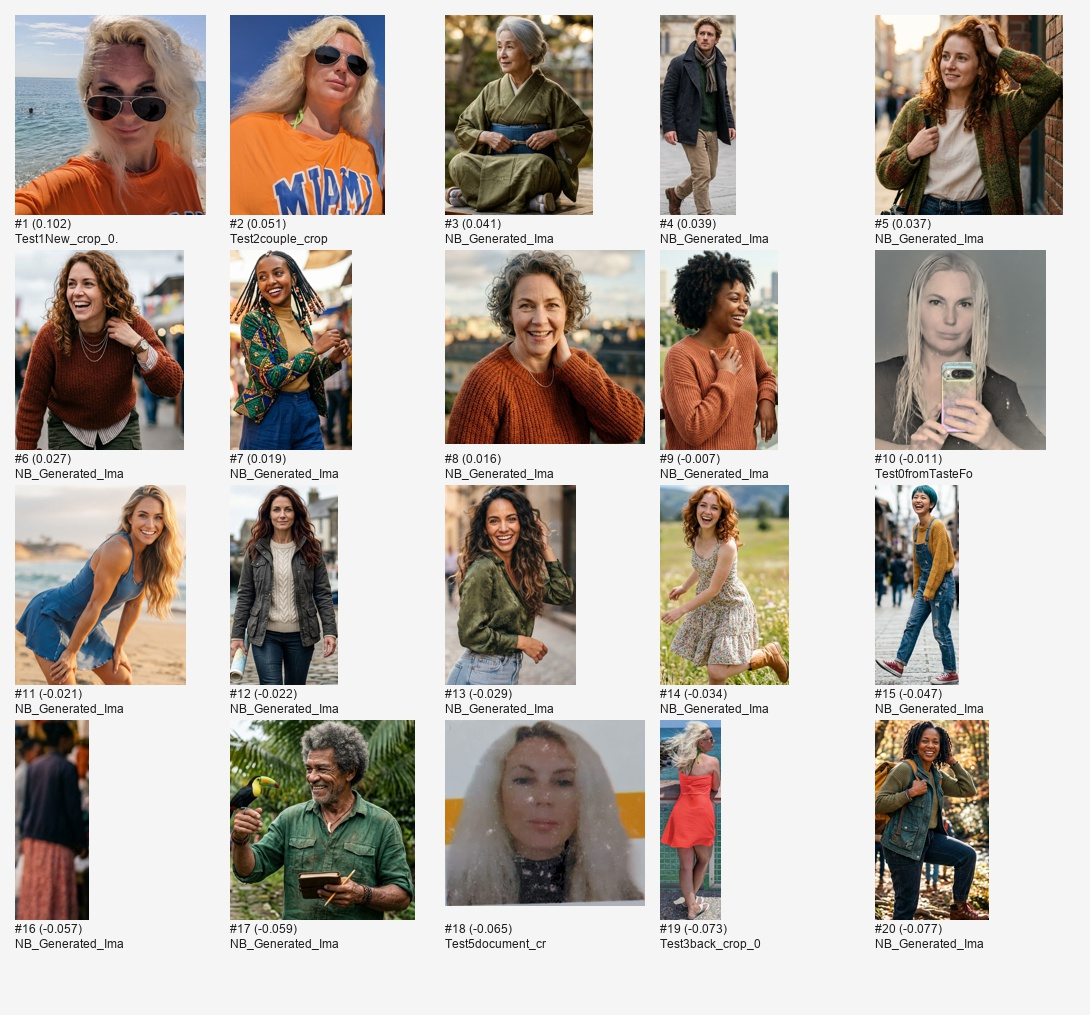

In [19]:
# ЯЧЕЙКА: Инференс SVM по кропам (04_tmp_crops), вывод лога и сетки
if RUN_SVM_PIPELINE:
    print("\n[СИСТЕМА] Анализ целевых лиц алгоритмом SVM по кэшированным кропам...")
    svm_path = os.path.join(model_dir, "oc_svm_model.pkl")
    
    if os.path.exists(svm_path):
        with open(svm_path, 'rb') as f:
            clf = pickle.load(f)
            
        # АНАЛИЗ СТРОГО ПО КРОПАМ ИЗ ПАПКИ 04_tmp_crops (сформированных JSON-пайплайном)
        test_files = [f for f in os.listdir(tmp_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg')) and "_crop_" in f]
        results_pool_svm = []

        for file in test_files:
            path = os.path.join(tmp_dir, file)
            feat = extract_features(path)
            if feat is not None:
                score = float(clf.decision_function(feat.reshape(1, -1))[0])
                results_pool_svm.append({
                    "score": score, 
                    "path": path, 
                    "filename": file
                })

        results_pool_svm.sort(key=lambda x: x["score"], reverse=True)
        top_20_svm = results_pool_svm[:20]

        # Дамп JSON кэша
        cache_file_svm = os.path.join(results_SVM_dir, "svm_inference_cache.json")
        with open(cache_file_svm, "w", encoding="utf-8") as f:
            json.dump(top_20_svm, f, ensure_ascii=False, indent=4)

        print("=== ТАБЛИЦА РЕЛЕВАНТНОСТИ (TOP-20) по алгоритму SVM ===")
        for rank, item in enumerate(top_20_svm, 1):
            print(f"#{rank:<4} | Score: {item['score']:.4f} | {item['filename']}")

        # Рендер сетки кропов
        cols, thumb_size, padding = 5, (200, 200), 15
        try:
            font = ImageFont.truetype("arial.ttf", 12)
        except:
            font = ImageFont.load_default()

        n_images = len(top_20_svm)
        rows = (n_images + cols - 1) // cols
        grid_width = cols * thumb_size[0] + (cols + 1) * padding
        grid_height = rows * (thumb_size[1] + 35) + (rows + 1) * padding
        
        grid_img = Image.new("RGB", (grid_width, grid_height), color=(245, 245, 245))
        draw = ImageDraw.Draw(grid_img)
        
        for idx, item in enumerate(top_20_svm):
            r, c = divmod(idx, cols)
            x = padding + c * (thumb_size[0] + padding)
            y = padding + r * (thumb_size[1] + 35)
            try:
                img = Image.open(item["path"]).convert("RGB")
                img.thumbnail(thumb_size)
                grid_img.paste(img, (x, y))
                caption = f"#{idx+1} ({item['score']:.3f})\n{item['filename'][:16]}"
                draw.text((x, y + thumb_size[1] + 2), caption, fill=(30, 30, 30), font=font)
            except:
                pass

        safe_output_path = os.path.join(results_SVM_dir, "top_20_grid_svm.jpg")
        grid_img.save(safe_output_path, quality=95)
        print(f"[СИСТЕМА] Графическая сетка аппаратно сохранена на SSD: {safe_output_path}")
        print(f"[СИСТЕМА] Данные инференса сохранены в кэш: {cache_file_svm}")
        
        display(IPyImage(filename=safe_output_path))
    else:
        print("[OШИБКА] Модель SVM не найдена.")
else:
    print("[СИСТЕМА] Пайплайн SVM отключен.")